# Classification avec pytorch RNN,LSTM,GRU

- author : Sylvie Dagoret-Campagne
- affiliation : IJCLab/IN2P3/CNRS
- creation date : 2025-11-07 (at NERSC **kernel desc-td-env-dev**)
- update : 2025-11-09 : finish implementation at NERSC
- last update : 2025-11-10 laptop on (**kernel pytorch-cpu-py312**)
- last update : 2025-11-11 at IDRIS with kernel **pytorch-gpu-2.8.0_py3.12.11**

1️⃣ Modèles séquentiels / temporels (RNN, LSTM, GRU)

- Les courbes de lumière sont naturellement des séries temporelles. Au lieu de résumer tout en features, tu peux traiter la séquence complète par bande :
- Input : MJD, flux, flux_err par bande
- RNN / LSTM / GRU → apprend la dynamique des variations de flux dans le temps
- Output : type de SN ou probabilité multi-classes
- 💡 Avantages : capture les formes des courbes (rise, plateau, décroissance)
- 💡 Inconvénients : plus gourmand en données et GPU, nécessite padding ou masking si les séquences ont des longueurs différentes

In [1]:
import torch.nn as nn

class SN_LSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, x):
        _, (hn, _) = self.lstm(x)  # hn: hidden state final
        out = self.fc(hn[-1])
        return out

- input_dim = 2 ou 3 (flux, flux_err, optionnellement bande encodée)
- hidden_dim : 32–128 suffisent pour commencer
- Prétraitement : séquences padding ou découpées à longueur fixe

2️⃣ Transformers / LLM pour séries temporelles
- Les transformers (ou petits LLMs) commencent à être utilisés pour les lightcurves :
- Input : séquence de tokens ou vecteurs (flux, MJD, bande)
- Attention apprend à se concentrer sur les points clés (pic, montée, décroissance)
- Output : classification multi-classes
- Avantages : meilleure capture des relations longues distances dans la série.
- Inconvénients : lourd, nécessite GPU, tuning complexe.
- Des implémentations existent sur Hugging Face :
- Modèles Time Series Transformer
- AstroNet et SuperNNova pour transients

3️⃣ Approche hybride
- Tu peux combiner features classiques + séquence complète :
- Extraire features globales (flux_max, flux_mean, rise_time)
- Coupler à une LSTM ou transformer pour capturer la dynamique
- Fusionner dans un réseau final (MLP) pour la classification

💡 Suggestion pour ton notebook NERSC :

- Commencer avec MLP sur features (déjà fait)
- Ensuite, préparer les séquences : MJD/flux par bande, padding, mask
- Tester LSTM/GRU sur un sous-échantillon pour vérifier performance et temps GPU
- Enfin, explorer Transformers si tu veux vraiment capturer les patterns complexes

## Prepare data

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import numpy as np
import pandas as pd
from astropy.io import fits
import glob
import random
import fitsio
import os
from typing import Optional,List,Dict,Tuple
import socket
import traceback
import psutil

In [3]:
import matplotlib.pyplot as plt

In [4]:
import sys
print(sys.executable)

/lustre/fshomisc/sup/hpe/pub/miniforge/24.11.3/envs/pytorch-gpu-2.8.0+py3.12.11/bin/python


In [5]:
#!ls /global/cfs/cdirs/lsst/www/DESC_TD_PUBLIC/ELASTICC/ELASTICC2_TRAINING_SAMPLE_2

## Function definitions

In [6]:
def is_on_system(system_hostnames: List[str], system_env_vars: List[str] = None) -> bool:
    """
    Check if the current environment matches a specific computing system.

    Args:
        system_hostnames: List of substrings to check in the hostname.
        system_env_vars: Optional list of environment variables to check.

    Returns:
        bool: True if the current environment matches the system, False otherwise.
    """
    hostname = socket.gethostname()

    # Check hostname
    host_check = any(system_host in hostname for system_host in system_hostnames)

    # Check environment variables if provided
    env_check = False
    if system_env_vars:
        env_check = any(var in os.environ for var in system_env_vars)

    return host_check or env_check

def is_on_nersc() -> bool:
    """Check if the current environment is a NERSC system."""
    nersc_hostnames = ["perlmutter", "cori", "nersc.gov"]
    nersc_env_vars = ["NERSC_HOST", "CRAY_SYSTEM_NAME"]
    return is_on_system(nersc_hostnames, nersc_env_vars)

def is_on_idris() -> bool:
    """Check if the current environment is an IDRIS Jean-Zay system."""
    idris_hostnames = ["jean-zay", "jean-zay2", "r3i4n5"]
    return is_on_system(idris_hostnames)

def get_system_name() -> str:
    """
    Determine the name of the current computing system.

    Returns:
        str: The name of the system ("NERSC", "IDRIS", or "Other").
    """
    if is_on_nersc():
        return "NERSC"
    elif is_on_idris():
        return "IDRIS"
    else:
        return "Other"

if __name__ == "__main__":
    system = get_system_name()
    if system == "NERSC":
        print("I am on a NERSC system.")
    elif system == "IDRIS":
        print("I am on an IDRIS Jean-Zay system.")
    else:
        print("I am on my laptop or another system.")


I am on an IDRIS Jean-Zay system.


In [7]:
def get_datapath() -> Optional[str]:
    """
    Get the appropriate data path based on the current computing environment.

    Returns:
        Optional[str]: The path to the DESC-TD public data directory for the current system.
                       Returns None if the path cannot be determined or doesn't exist.

    Raises:
        EnvironmentError: If the required environment variables are missing on IDRIS.
    """
    # Define base paths for each system
    system_paths = {
        "NERSC": "/global/cfs/cdirs/lsst/www/DESC_TD_PUBLIC/ELASTICC/ELASTICC2_TRAINING_SAMPLE_2",
        "IDRIS": None,  # Will be constructed dynamically
        "LOCAL": "/Users/dagoret/DATA/DESC_TD_PUBLIC/ELASTICC/ELASTICC2_TRAINING_SAMPLE_2"
    }

    # Determine the current system
    #from your_module import is_on_nersc, is_on_idris  # Import your system detection functions

    if is_on_nersc():
        print("NERSC configuration: Using NERSC-specific paths.")
        path = system_paths["NERSC"]

    elif is_on_idris():
        print("IDRIS configuration: Using IDRIS-specific paths.")
        try:
            # Get the WORK environment variable
            WORK_PATH = os.getenv("WORK")
            if not WORK_PATH:
                raise EnvironmentError("WORK environment variable not set on IDRIS.")

            # Construct the full path
            relative_path = "DESC/DESC_TD_PUBLIC/ELASTICC/ELASTICC2_TRAINING_SAMPLE_2/ELASTICC/ELASTICC2_TRAINING_SAMPLE_2"
            #path = os.path.join(WORK_PATH, relative_path)
            path = WORK_PATH + "/DESC/DESC_TD_PUBLIC/ELASTICC/ELASTICC2_TRAINING_SAMPLE_2/ELASTICC/ELASTICC2_TRAINING_SAMPLE_2/"

        except Exception as e:
            print(f"Error determining IDRIS path: {e}")
            return None

    else:
        print("Local configuration: Using local resources.")
        path = system_paths["LOCAL"]

    # Verify the path exists
    if not os.path.exists(path):
        print(f"Warning: The specified path does not exist: {path}")
        return None

    return path


In [8]:
def build_dict_objtype_from_file(path_top: str, obj_type_list: List[str]) -> Dict[str, Dict[str, List[str]]]:
    """
    Build a dictionary mapping each object type to its corresponding ELASTIC2 header and photometric FITS files.

    Parameters
    ----------
    path_top : str
        Root directory containing subdirectories for each object type.
    obj_type_list : List[str]
        List of object type names (each corresponding to a subdirectory).

    Returns
    -------
    Dict[str, Dict[str, List[str]]]
        A dictionary with the following structure:
        {
            "OBJTYPE1": {
                "head_files": ["/path/to/file1_HEAD.FITS.gz", ...],
                "phot_files": ["/path/to/file1_PHOT.FITS.gz", ...]
            },
            ...
        }
    """
    dict_objtype_to_files: Dict[str, Dict[str, List[str]]] = {}

    for obj_type in obj_type_list:
        path = os.path.join(path_top, obj_type)

        if not os.path.isdir(path):
            print(f"⚠️  Warning: directory not found for object type '{obj_type}' — skipping.")
            continue

        head_pattern = os.path.join(path, "*_HEAD.FITS.gz")
        phot_pattern = os.path.join(path, "*_PHOT.FITS.gz")

        head_files = sorted(glob.glob(head_pattern))
        phot_files = sorted(glob.glob(phot_pattern))

        if not head_files and not phot_files:
            print(f"⚠️  No FITS files found in {path}")

        dict_objtype_to_files[obj_type] = {
            "head_files": head_files,
            "phot_files": phot_files
        }

    return dict_objtype_to_files


In [9]:
def load_lightcurve(head_file: str, phot_file: str, lctype: str) -> Tuple[pd.DataFrame, np.recarray]:
    """
    Load a single light curve from ELASTIC2-format FITS files.

    Parameters
    ----------
    head_file : str
        Path to the *_HEAD.FITS.gz file (contains metadata for the light curve).
    phot_file : str
        Path to the *_PHOT.FITS.gz file (contains the photometric time series).
    lctype : str
        Label identifying the light-curve type (e.g., 'Ia', 'Ibc', 'CC').

    Returns
    -------
    df : pandas.DataFrame
        A DataFrame containing:
        - SNID: supernova identifier
        - LCTYPE: light-curve type
        - MJD: Modified Julian Date
        - BAND: photometric band (string)
        - FLUXCAL: calibrated flux
        - FLUXCALERR: flux uncertainty

    head : numpy.recarray
        Header table (from the HEAD FITS extension).
    """
    # Use context managers to ensure files are properly closed
    with fits.open(head_file, memmap=True) as hdul_head, fits.open(phot_file, memmap=True) as hdul_phot:
        head = hdul_head[1].data
        phot = hdul_phot[1].data

        snid = str(head["SNID"][0]).strip()

        # Convert columns to pandas DataFrame efficiently
        #df = pd.DataFrame({
        #    "SNID": snid,
        #    "LCTYPE": lctype,
        #    "MJD": phot["MJD"].byteswap().newbyteorder('<'),
        #    "BAND": np.char.strip(phot["BAND"].astype(str)),
        #    "FLUXCAL": phot["FLUXCAL"].byteswap().newbyteorder('<'),
        #    "FLUXCALERR": phot["FLUXCALERR"].byteswap().newbyteorder('<')
        #})
        df = pd.DataFrame({
            "SNID": snid,
            "LCTYPE": lctype,
            "MJD": phot["MJD"],
            "BAND": np.char.strip(phot["BAND"].astype(str)),
            "FLUXCAL": phot["FLUXCAL"],
            "FLUXCALERR": phot["FLUXCALERR"]
        })


        # Forcer le little-endian pour toutes les colonnes float ou int
        for col in ["MJD", "FLUXCAL", "FLUXCALERR"]:
            df[col] = df[col].astype(df[col].dtype.newbyteorder('<'))

    return df, head


In [10]:

def reduce_lightcurve_noise_advanced(
    df: pd.DataFrame,
    snr_strong: float = 3.0,
    snr_weak: float = 1.0,
    frac_weak_max: float = 0.2,
    min_points_per_band: int = 10
) -> pd.DataFrame:
    """
    Reduce the number of noisy points in a light curve while preserving temporal distribution.

    Parameters
    ----------
    df : pd.DataFrame
        Must contain ["MJD", "BAND", "FLUXCAL", "FLUXCALERR"].
    snr_strong : float
        S/N threshold above which all points are kept.
    snr_weak : float
        S/N threshold below which points are considered weak/noise.
    frac_weak_max : float
        Maximum fraction of weak points to keep.
    min_points_per_band : int
        Minimum number of points to keep per band to avoid empty bands.

    Returns
    -------
    pd.DataFrame
        Filtered DataFrame with reduced noise but preserved temporal coverage.
    """

    reduced_list = []

    for band, d in df.groupby("BAND"):
        snr = np.abs(d["FLUXCAL"]) / d["FLUXCALERR"]

        strong = d[snr >= snr_strong]
        weak = d[snr < snr_weak]
        mid = d[(snr >= snr_weak) & (snr < snr_strong)]

        if len(weak) > 0:
            weak_sorted = weak.sort_values("MJD")
            mjd_diff = np.diff(weak_sorted["MJD"].values)

            # Safe density factor computation
            if len(mjd_diff) == 0 or np.max(mjd_diff) == 0:
                frac_weak = frac_weak_max
            else:
                density_factor = np.median(mjd_diff) / np.max(mjd_diff)
                if np.isnan(density_factor) or density_factor == 0:
                    frac_weak = frac_weak_max
                else:
                    frac_weak = min(frac_weak_max / density_factor, 1.0)

            n_keep = max(min_points_per_band, int(len(weak_sorted) * frac_weak))
            # Uniformly sample weak points
            idx = np.linspace(0, len(weak_sorted) - 1, n_keep, dtype=int)
            weak_sampled = weak_sorted.iloc[idx]
        else:
            weak_sampled = pd.DataFrame(columns=d.columns)

        reduced_band = pd.concat([strong, mid, weak_sampled]).sort_values("MJD")
        reduced_list.append(reduced_band)

    return pd.concat(reduced_list).reset_index(drop=True)


In [11]:
def load_all_lightcurves(
    nf: int,
    dict_objtype_to_files: Dict[str, Dict[str, List[str]]],
    verbose: bool = True
) -> List[Tuple[pd.DataFrame, object]]:
    """
    Load multiple light curves from a structured dictionary of file paths.

    Parameters
    ----------
    nf : int
        Maximum number of light curves to load per object type.
    dict_objtype_to_files : dict
        Dictionary of the form:
        {
            "OBJTYPE1": {
                "head_files": [...],
                "phot_files": [...]
            },
            ...
        }
    verbose : bool, optional
        If True (default), print progress and error messages.

    Returns
    -------
    lightcurves : List[Tuple[pd.DataFrame, object]]
        A list of (dataframe, head) tuples, one per loaded light curve.
    """
    lightcurves = []

    for obj_type, file_dict in dict_objtype_to_files.items():
        head_files = file_dict.get("head_files", [])
        phot_files = file_dict.get("phot_files", [])

        if not head_files or not phot_files:
            if verbose:
                print(f"⚠️  No files found for object type '{obj_type}'. Skipping.")
            continue

        n_to_load = min(nf, len(head_files), len(phot_files))
        if verbose:
            print(f"🔹 Loading {n_to_load} lightcurves for '{obj_type}'...")

        for i, (h, p) in enumerate(zip(head_files[:nf], phot_files[:nf]), start=1):
            try:
                df, head = load_lightcurve(h, p, obj_type)
                lightcurves.append((df, head))
            except Exception as e:
                if verbose:
                    print(f"❌ Error loading {obj_type} [{i}/{n_to_load}] - {h}")
                    print(f"   {e}")
                    # Optional: uncomment to debug deeply
                    # traceback.print_exc()

    if verbose:
        print(f"✅ Loaded {len(lightcurves)} lightcurves total.")

    return lightcurves


In [12]:
def plot_lightcurve(
    df: pd.DataFrame,
    title: str | None = None,
    flux_unit: str = "Flux (FLUXCAL)",
    mjd_offset: float | None = None,
    show_legend: bool = True,
    figsize: tuple[int, int] = (18, 6),
    savepath: str | None = None,
    show: bool = True
) -> None:
    """
    Plot a light curve with error bars for each photometric band,
    using realistic colors for each band.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame containing at least columns: 'MJD', 'BAND', 'FLUXCAL', 'FLUXCALERR'.
    title : str, optional
        Plot title.
    flux_unit : str, optional
        Label for the y-axis (default: "Flux (FLUXCAL)").
    mjd_offset : float, optional
        Subtract this value from MJD for plotting.
    show_legend : bool, optional
        Whether to show a legend (default: True).
    figsize : tuple[int, int], optional
        Figure size in inches.
    savepath : str, optional
        Path to save the figure.
    show : bool, optional
        Whether to display the figure.
    """

    if df.empty:
        print("⚠️  Empty DataFrame — nothing to plot.")
        return

    required_cols = {"MJD", "BAND", "FLUXCAL", "FLUXCALERR"}
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns in DataFrame: {missing}")

    plt.figure(figsize=figsize)

    # Define realistic colors for bands
    band_colors = {
        "u": "#6A5ACD",   # violet/blue
        "g": "#2E8B57",   # green
        "r": "#DC143C",   # red
        "i": "#FF8C00",   # orange
        "z": "#8B4513",   # brownish
        "Y": "#800000",   # dark red / infrared
    }

    bands = sorted(df["BAND"].unique())

    for band in bands:
        b = band.strip()
        if b == "-":
            continue

        d = df[df["BAND"] == band].sort_values("MJD")
        mjd = d["MJD"] - (mjd_offset if mjd_offset else 0)

        color = band_colors.get(b, "#808080")  # fallback grey if band unknown

        plt.errorbar(
            mjd,
            d["FLUXCAL"],
            yerr=d["FLUXCALERR"],
            fmt="o",
            ms=3,
            color=color,
            label=b,
            alpha=0.8,
            capsize=3,
        )

    plt.xlabel(f"MJD{' - ' + str(mjd_offset) if mjd_offset else ''}")
    plt.ylabel(flux_unit)
    plt.grid(True, linestyle="--", alpha=0.4)

    if title:
        plt.title(title, fontsize=13)

    if show_legend:
        plt.legend(title="Band")

    plt.tight_layout()

    if savepath:
        os.makedirs(os.path.dirname(savepath), exist_ok=True)
        plt.savefig(savepath, dpi=150, bbox_inches="tight")
        print(f"💾 Saved plot to: {savepath}")

    if show:
        plt.show()
    else:
        plt.close()


In [13]:
# ============================================================
# Prepare sequences: (Δt, flux, band)
# This function processes a DataFrame of photometric observations
# into normalized time differences (Δt), normalized flux, and band indices.
# ============================================================
band_to_idx = {'u': 0, 'g': 1, 'r': 2, 'i': 3, 'z': 4, 'Y': 5}

def make_sequence(df):
    """
    Convert a DataFrame of photometric observations into a sequence tensor.

    Args:
        df (pd.DataFrame): DataFrame containing columns 'MJD', 'FLUXCAL', and 'BAND'.

    Returns:
        seq (torch.Tensor): Tensor of shape (num_observations, 2),
                            where each row is [normalized_Δt, normalized_flux].
        bands (torch.Tensor): Tensor of band indices (as integers) for each observation.
    """
    # --- Step 1: Data Cleaning ---
    # Remove observations with invalid/missing band information
    df = df[df["BAND"] != "-"].copy()  # Use .copy() to avoid SettingWithCopyWarning
    # Sort observations by Modified Julian Date (MJD) to ensure chronological order
    df = df.sort_values('MJD')

    # --- Step 2: Extract and Preprocess Data ---
    mjd = df['MJD'].values  # Modified Julian Date (time of observation)
    flux = df['FLUXCAL'].values  # Calibrated flux values
    # Convert band names (e.g., 'g', 'r') to integer indices using the predefined mapping
    band = np.array([band_to_idx[b] for b in df['BAND'].values])

    # --- Step 3: Normalize Time Differences (Δt) ---
    # Compute time differences relative to the first observation
    dt = np.diff(mjd, prepend=mjd[0])  # Δt: time since first observation
    # Normalize Δt: subtract mean and divide by standard deviation
    # Add small epsilon (1e-6) to avoid division by zero
    dt = (dt - dt.mean()) / (dt.std() + 1e-6)

    # --- Step 4: Normalize Flux ---
    # Normalize flux: subtract mean and divide by standard deviation
    # Add small epsilon (1e-6) to avoid division by zero
    flux = (flux - flux.mean()) / (flux.std() + 1e-6)

    # --- Step 5: Stack and Convert to Tensors ---
    # Stack normalized Δt and flux into a 2D array (shape: num_observations x 2)
    seq = torch.tensor(np.stack([dt, flux], axis=1), dtype=torch.float32)
    # Convert band indices to a tensor of type long (for integer labels)
    bands = torch.tensor(band, dtype=torch.long)

    return seq, bands


## Start 

In [14]:
# -----------------------------
# 2️⃣ Définir les chemins NERSC
# -----------------------------

In [15]:
os.getenv("WORK")

'/lustre/fswork/projects/rech/cxj/uab37dk'

In [16]:
!ls /lustre/fswork/projects/rech/cxj/uab37dk/DESC/DESC_TD_PUBLIC/ELASTICC/ELASTICC2_TRAINING_SAMPLE_2

ELASTICC  robots.txt


In [17]:
# 2️⃣ Définir le chemin des données et types à analyser
if is_on_nersc():
    print("Configuration pour NERSC : utilisation des GPU ou des chemins spécifiques.")
    # Exemple : charger des données depuis un chemin NERSC
    BASE_PATH = "/global/cfs/cdirs/lsst/www/DESC_TD_PUBLIC/ELASTICC/ELASTICC2_TRAINING_SAMPLE_2"

if is_on_idris():
    WORK_PATH = os.getenv("WORK")
    #BASE_PATH = os.path.join(WORK_PATH,"/DESC/DESC_TD_PUBLIC/ELASTICC/ELASTICC2_TRAINING_SAMPLE_2/ELASTICC/ELASTICC2_TRAINING_SAMPLE_2/")
    BASE_PATH = WORK_PATH + "/DESC/DESC_TD_PUBLIC/ELASTICC/ELASTICC2_TRAINING_SAMPLE_2/ELASTICC/ELASTICC2_TRAINING_SAMPLE_2/"
else:
    print("Configuration pour laptop : utilisation des ressources locales.")
    # Exemple : charger des données depuis un chemin local
    BASE_PATH = "/Users/dagoret/DATA/DESC_TD_PUBLIC/ELASTICC/ELASTICC2_TRAINING_SAMPLE_2"

In [18]:
BASE_PATH = get_datapath()

IDRIS configuration: Using IDRIS-specific paths.


In [19]:
print(BASE_PATH)

/lustre/fswork/projects/rech/cxj/uab37dk/DESC/DESC_TD_PUBLIC/ELASTICC/ELASTICC2_TRAINING_SAMPLE_2/ELASTICC/ELASTICC2_TRAINING_SAMPLE_2/


In [20]:
# Répertoire d'un type de SN
sample_types = [
    "ELASTICC2_TRAIN_02_SNIa-SALT3",
    "ELASTICC2_TRAIN_02_SNIc-Templates",
    "ELASTICC2_TRAIN_02_SNIb-Templates"]

dict_sntype_to_files = build_dict_objtype_from_file(path_top = BASE_PATH, obj_type_list = sample_types )

In [21]:
#dict_sntype_to_files

In [22]:
# -----------------------------
# 3️⃣ Lire un HEAD aléatoire
# -----------------------------
# select the first type of SN
sntype = list(dict_sntype_to_files.keys())[0]

PATH = os.path.join(BASE_PATH,sntype)

#then specify the path
head_files = dict_sntype_to_files[sntype]["head_files"]

head_file = os.path.join(PATH, random.choice(head_files))
head_data = fitsio.FITS(head_file)[1].read()
print("Colonnes HEAD :", head_data.dtype.names)
print("Exemple HEAD :\n", head_data[:1])

Colonnes HEAD : ('SNID', 'IAUC', 'FAKE', 'RA', 'DEC', 'PIXSIZE', 'NXPIX', 'NYPIX', 'SNTYPE', 'NOBS', 'PTROBS_MIN', 'PTROBS_MAX', 'MWEBV', 'MWEBV_ERR', 'REDSHIFT_HELIO', 'REDSHIFT_HELIO_ERR', 'REDSHIFT_FINAL', 'REDSHIFT_FINAL_ERR', 'VPEC', 'VPEC_ERR', 'HOSTGAL_NMATCH', 'HOSTGAL_NMATCH2', 'HOSTGAL_OBJID', 'HOSTGAL_FLAG', 'HOSTGAL_PHOTOZ', 'HOSTGAL_PHOTOZ_ERR', 'HOSTGAL_SPECZ', 'HOSTGAL_SPECZ_ERR', 'HOSTGAL_RA', 'HOSTGAL_DEC', 'HOSTGAL_SNSEP', 'HOSTGAL_DDLR', 'HOSTGAL_CONFUSION', 'HOSTGAL_LOGMASS', 'HOSTGAL_LOGMASS_ERR', 'HOSTGAL_LOGSFR', 'HOSTGAL_LOGSFR_ERR', 'HOSTGAL_LOGsSFR', 'HOSTGAL_LOGsSFR_ERR', 'HOSTGAL_COLOR', 'HOSTGAL_COLOR_ERR', 'HOSTGAL_ELLIPTICITY', 'HOSTGAL_OBJID2', 'HOSTGAL_SQRADIUS', 'HOSTGAL_OBJID_UNIQUE', 'HOSTGAL_ZPHOT_Q000', 'HOSTGAL_ZPHOT_Q010', 'HOSTGAL_ZPHOT_Q020', 'HOSTGAL_ZPHOT_Q030', 'HOSTGAL_ZPHOT_Q040', 'HOSTGAL_ZPHOT_Q050', 'HOSTGAL_ZPHOT_Q060', 'HOSTGAL_ZPHOT_Q070', 'HOSTGAL_ZPHOT_Q080', 'HOSTGAL_ZPHOT_Q090', 'HOSTGAL_ZPHOT_Q100', 'HOSTGAL_MAG_u', 'HOSTGAL_MAG

### Load a number of SN samples

In [23]:
NF= 50
lightcurves = load_all_lightcurves(NF, dict_sntype_to_files)
print(f"{len(lightcurves)} curves loaded")

🔹 Loading 40 lightcurves for 'ELASTICC2_TRAIN_02_SNIa-SALT3'...
🔹 Loading 40 lightcurves for 'ELASTICC2_TRAIN_02_SNIc-Templates'...
🔹 Loading 40 lightcurves for 'ELASTICC2_TRAIN_02_SNIb-Templates'...
✅ Loaded 120 lightcurves total.
120 curves loaded


### Reduce the light curves

In [24]:
lightcurves_reduced = []
count = 0
for lc,head in lightcurves:
    count += 1
    lc_red = reduce_lightcurve_noise_advanced(lc,
                                              snr_strong=3.0,
                                              snr_weak=1.0,
                                              frac_weak_max=0.1,
                                              min_points_per_band=10)
    
    lightcurves_reduced.append((lc_red,head)) 
    

## Plot First Light Curve

In [25]:
NLC = len(lightcurves_reduced) 
index = np.random.randint(0, NLC)
title_lc = lightcurves_reduced[index][0]['LCTYPE'].unique()[0] + " : "  + "SNID " +  str(lightcurves_reduced[index][0]['SNID'].unique()[0])

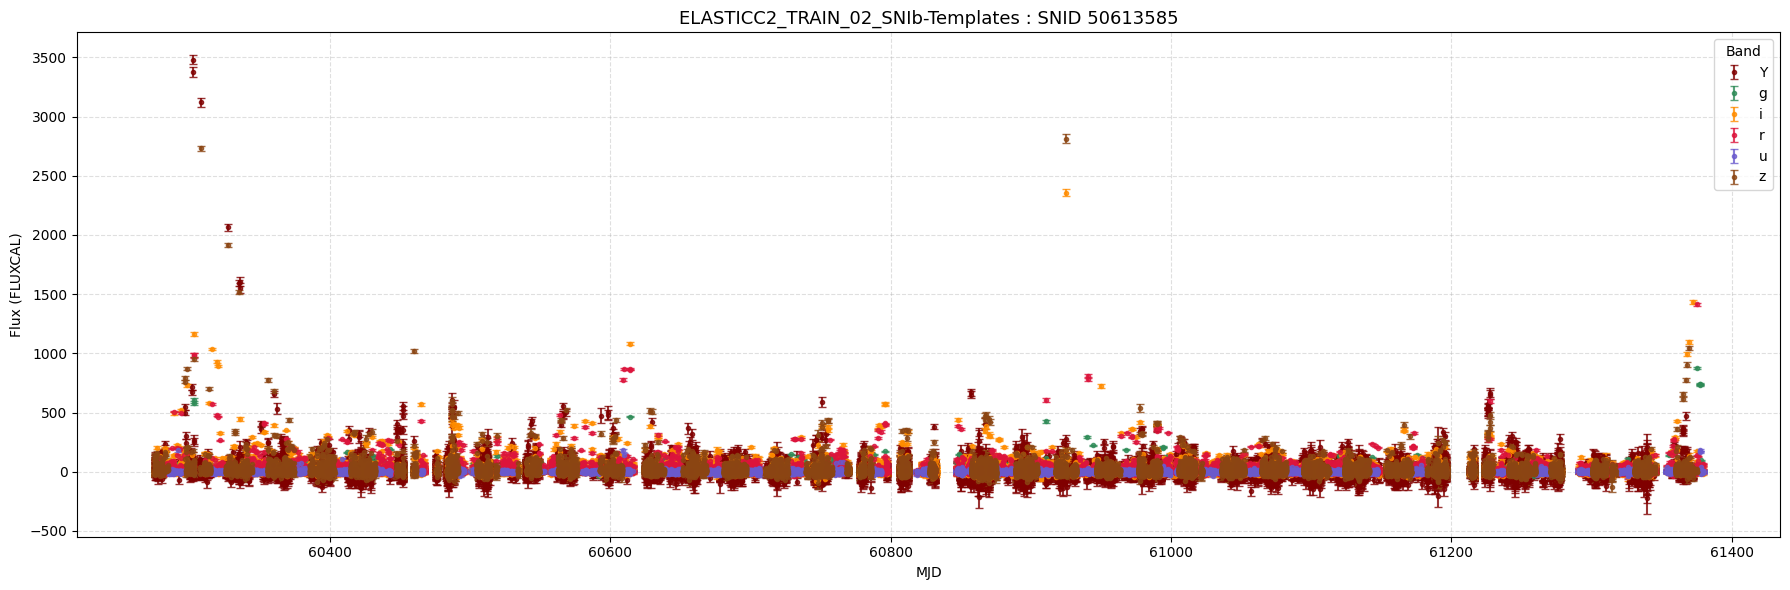

In [26]:
plot_lightcurve(lightcurves_reduced[index][0], title=title_lc)

In [27]:
assert False

AssertionError: 

### Generate sequences

In [ ]:
print(len(lightcurves))
print(sys.getsizeof(lightcurves))

In [ ]:
print(f"{psutil.Process(os.getpid()).memory_info().rss / 1e9:.2f} GB")

In [ ]:
sequences, bands_list, labels = [], [], []

count = 0
for df, head in lightcurves:
    try:
        count += 1
        # Extract flux sequence and spectral bands

        #print(">>> df.types = ",df.dtypes)
        #print(">>> Processing:", head)
        print(f">>> Virtual memory {count}:",psutil.virtual_memory())
        
        seq, bands = make_sequence(df)

        # Check that sequence and bands are not empty
        if seq is not None and bands is not None and len(seq) > 0 and len(bands) > 0:
            sequences.append(seq)
            bands_list.append(bands)

            # Extract supernova type (LCTYPE) and convert to index
            lctype = df['LCTYPE'].unique()
            if len(lctype) > 0:
                label = sample_types.index(lctype[0])
                labels.append(label)
            else:
                print(f"No type (LCTYPE) found for DataFrame: {head}")
                continue  # Skip to the next iteration
        else:
            print(f"Empty sequence or bands for DataFrame: {head}")
            continue  # Skip to the next iteration

    except KeyError as e:
        # Handle errors related to missing columns (e.g., 'LCTYPE')
        print(f"Key error (missing column) for DataFrame {head}: {e}")
        continue

    except ValueError as e:
        # Handle errors related to unexpected values (e.g., LCTYPE not found in sample_types)
        print(f"Value error for DataFrame {head}: {e}")
        continue

    except Exception as e:
        # Handle any other unexpected error
        print(f"Unexpected error for DataFrame {head}: {e}")
        continue

# Check the sizes of the lists
print(f"Number of sequences: {len(sequences)}")
print(f"Number of band lists: {len(bands_list)}")
print(f"Number of labels: {len(labels)}")

# Optional: Ensure all lists have the same length
assert len(sequences) == len(bands_list) == len(labels), "Lists do not have the same length!"


### Generate paded sequences

In [ ]:
lengths = [len(s) for s in sequences]
print("N sequences:", len(lengths))
print("Max length:", max(lengths))
print("Mean length:", sum(lengths)/len(lengths))

In [ ]:
assert False

In [ ]:
lengths = torch.tensor([len(s) for s in sequences])
padded_seq = pad_sequence(sequences, batch_first=True)
padded_bands = pad_sequence(bands_list, batch_first=True, padding_value=-1)
labels = torch.tensor(labels)

### Dataset et DataLoader

In [ ]:
# ============================================================
# Dataset et DataLoader
# ============================================================

class LightCurveDataset(Dataset):
    def __init__(self, seqs, bands, lengths, labels):
        self.seqs = seqs
        self.bands = bands
        self.lengths = lengths
        self.labels = labels
    def __len__(self): return len(self.labels)
    def __getitem__(self, i):
        return self.seqs[i], self.bands[i], self.lengths[i], self.labels[i]


In [ ]:
dataset = LightCurveDataset(padded_seq, padded_bands, lengths, labels)
loader = DataLoader(dataset, batch_size=8, shuffle=True)

### Modèle avec embedding de bande et LSTM

In [ ]:
# ============================================================
# Modèle avec embedding de bande et LSTM
# ============================================================

class LightCurveLSTM_Enhanced(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=128, num_layers=1, num_classes=3, num_bands=6, band_emb_dim=4):
        super().__init__()
        self.band_emb = nn.Embedding(num_embeddings=num_bands, embedding_dim=band_emb_dim)
        self.lstm = nn.LSTM(input_dim + band_emb_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x, bands, lengths):
        bands_clamped = bands.clamp(min=0)  # pour padding = -1
        emb = self.band_emb(bands_clamped)
        x = torch.cat([x, emb], dim=2)
        packed = nn.utils.rnn.pack_padded_sequence(x, lengths, batch_first=True, enforce_sorted=False)
        _, (h, _) = self.lstm(packed)
        out = self.fc(h[-1])
        return out


### Entraînement

In [ ]:
# ============================================================
# Entraînement
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LightCurveLSTM_Enhanced(num_classes=len(sample_types)).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

for epoch in range(10):
    model.train()
    total_loss = 0
    for x, b, l, y in loader:
        x, b, l, y = x.to(device), b.to(device), l.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x, b, l)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}: loss={total_loss/len(loader):.4f}")

### Évaluation

In [ ]:
# ============================================================
# Évaluation
# ============================================================

model.eval()
with torch.no_grad():
    out = model(padded_seq.to(device), padded_bands.to(device), lengths.to(device))
    pred = out.argmax(dim=1)
    acc = (pred.cpu() == labels).float().mean().item()

print(f"\n✅ Accuracy globale : {acc:.3f}")

💬 Explications clés

| Élément                | Rôle                                                            |
| ---------------------- | --------------------------------------------------------------- |
| `Δt`                   | Encode l’irrégularité temporelle, essentiel pour le RNN         |
| `flux`                 | Valeur photométrique normalisée                                 |
| `band_emb`             | Transforme l’indice de bande (u,g,r,i,z,Y) en un vecteur appris |
| `pack_padded_sequence` | Ignore les zéros de padding pour un apprentissage propre        |
| `LSTM`                 | Capture la dynamique temporelle du flux                         |
| `fc`                   | Prédit le type de SN à partir du dernier état caché             |


ChatGPT a dit :

Parfait 🌟

Voici la version améliorée du modèle ELASTICC avec :

un masque de padding explicite,

une architecture modulaire qui peut basculer facilement entre LSTM, GRU, ou Transformer Encoder,

une préparation des masques compatible avec les séquences irrégulières et padées.

Tu pourras ainsi, sans changer tes données, tester des architectures modernes de traitement de séries temporelles astrophysiques.

In [ ]:
# ============================================================
# Version améliorée du modèle : LSTM / GRU / Transformer
# avec masque de padding explicite
# ============================================================

import torch
import torch.nn as nn

class LightCurveModel(nn.Module):
    """
    Modèle pour séquences irrégulières de courbes de lumière :
      - encode les bandes via embedding
      - supporte LSTM, GRU ou TransformerEncoder
      - gère un masque de padding explicite
    """
    def __init__(self, 
                 input_dim=2,          # [Δt, flux]
                 band_emb_dim=4,       # embedding pour les bandes
                 hidden_dim=128,
                 num_layers=1,
                 num_classes=3,
                 num_bands=6,
                 model_type="lstm",    # "lstm", "gru" ou "transformer"
                 n_heads=4):
        super().__init__()
        self.model_type = model_type.lower()
        self.band_emb = nn.Embedding(num_embeddings=num_bands, embedding_dim=band_emb_dim)
        self.input_dim = input_dim + band_emb_dim

        if self.model_type == "lstm":
            self.rnn = nn.LSTM(self.input_dim, hidden_dim, num_layers, batch_first=True)
        elif self.model_type == "gru":
            self.rnn = nn.GRU(self.input_dim, hidden_dim, num_layers, batch_first=True)
        elif self.model_type == "transformer":
            encoder_layer = nn.TransformerEncoderLayer(d_model=self.input_dim, nhead=n_heads, batch_first=True)
            self.rnn = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
            hidden_dim = self.input_dim  # pour cohérence
        else:
            raise ValueError("model_type doit être 'lstm', 'gru' ou 'transformer'.")

        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x, bands, lengths):
        """
        x: (batch, seq_len, 2)
        bands: (batch, seq_len)
        lengths: (batch,)
        """
        # Embedding des bandes
        bands_clamped = bands.clamp(min=0)
        emb = self.band_emb(bands_clamped)
        x = torch.cat([x, emb], dim=2)

        # Masque de padding : True = doit être masqué
        max_len = x.size(1)
        mask = torch.arange(max_len, device=lengths.device)[None, :] >= lengths[:, None]

        if self.model_type in ["lstm", "gru"]:
            packed = nn.utils.rnn.pack_padded_sequence(x, lengths, batch_first=True, enforce_sorted=False)
            packed_out, hidden = self.rnn(packed)
            if self.model_type == "lstm":
                _, (h, _) = hidden
            else:
                _, h = None, hidden
            out = self.fc(h[-1])
        else:  # Transformer
            # TransformerEncoder attend mask=(batch, seq_len)
            out_seq = self.rnn(x, src_key_padding_mask=mask)
            # On prend le dernier état non masqué pour chaque séquence
            last_indices = (lengths - 1).clamp(min=0)
            last_outputs = out_seq[torch.arange(len(last_indices)), last_indices]
            out = self.fc(last_outputs)

        return out


###  ⚙️ Utilisation (LSTM, GRU, Transformer)

Exemple d’instanciation :

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Choisir le type de modèle :
model = LightCurveModel(
    input_dim=2, hidden_dim=128, num_layers=2,
    num_classes=len(sample_types), num_bands=6, 
    model_type="transformer"   # ou "lstm" / "gru"
).to(device)


### Entraînement (inchangé)

Tu peux réutiliser exactement la même boucle d’entraînement que précédemment :

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

for epoch in range(10):
    model.train()
    total_loss = 0
    for x, b, l, y in loader:
        x, b, l, y = x.to(device), b.to(device), l.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x, b, l)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}: loss={total_loss/len(loader):.4f}")


### Evaluation

In [ ]:
model.eval()
with torch.no_grad():
    out = model(padded_seq.to(device), padded_bands.to(device), lengths.to(device))
    pred = out.argmax(dim=1)
    acc = (pred.cpu() == labels).float().mean().item()

print(f"✅ Accuracy globale : {acc:.3f}")


### 💡 Avantages de cette version

| Fonctionnalité                         | Description                                                 |
| -------------------------------------- | ----------------------------------------------------------- |
| ✅ **Masque explicite**                 | les pas de temps “padés” sont ignorés par le modèle         |
| 🔄 **Modèle interchangeable**          | `model_type="lstm"`, `"gru"` ou `"transformer"`             |
| 🧠 **Embeddings de bandes**            | apprend à associer des patterns photométriques par filtre   |
| 🔥 **Transformer compatible**          | gère naturellement les longueurs variables via le masque    |
| 🪶 **Sortie adaptée à classification** | le dernier état (non masqué) de chaque séquence est utilisé |


Tu as maintenant un pipeline complet pour travailler sur les courbes de lumière irrégulières avec PyTorch, et tu peux expérimenter LSTM, GRU ou Transformer avec embeddings de bandes et masques de padding.

Prends le temps d’explorer chaque étape : préparation des séquences, normalisation, embeddings, et architectures. Ça te donnera une base solide pour classifier ou prédire des flux temporels.

Si tu veux, la prochaine fois on pourra aller encore plus loin avec positional encoding basé sur Δt pour Transformers, ou même des Neural ODEs pour séries temporelles continues. 🚀

Bon courage pour l’étude, et tu auras un super modèle astrophysique prêt à l’emploi ! 🌌

Veux‑tu que je te prépare un petit résumé visuel de ce pipeline pour t’aider à t’y retrouver plus facilement quand tu reviendras ?

- Parfait 🌟, voici un résumé visuel et conceptuel du pipeline RNN/LSTM/Transformer pour les courbes de lumière irrégulières.

```

┌──────────────────────────┐
│ Chargement des fichiers  │
│  - HEAD.FITS.gz          │
│  - PHOT.FITS.gz          │
└─────────┬────────────────┘
          │
          ▼
┌──────────────────────────┐
│ Extraction DataFrame     │
│  Colonnes :              │
│  - MJD                   │
│  - FLUXCAL / FLUXCALERR  │
│  - BAND                  │
│  - SNID, LCTYPE          │
└─────────┬────────────────┘
          │
          ▼
┌──────────────────────────┐
│ Préparation séquences     │
│  Pour chaque courbe :     │
│  - Trier par MJD          │
│  - Calcul Δt = diff(MJD)  │
│  - Normaliser flux        │
│  - Convertir band → idx   │
│  - Tensor : [Δt, flux]   │
│  - Tensor bands           │
└─────────┬────────────────┘
          │
          ▼
┌──────────────────────────┐
│ Padding pour batch        │
│  - pad_sequence           │
│  - lengths                │
│  - mask_padding (True=pad)│
└─────────┬────────────────┘
          │
          ▼
┌──────────────────────────┐
│ Modèle PyTorch            │
│  - Embedding bandes       │
│  - LSTM / GRU / Transformer│
│  - Input = [Δt, flux, band_emb]│
│  - Gestion padding/masque │
│  - Dernier hidden → FC    │
│  - Output = probabilité classe SN │
└─────────┬────────────────┘
          │
          ▼
┌──────────────────────────┐
│ Entraînement              │
│  - CrossEntropyLoss       │
│  - Optimizer : Adam       │
│  - Batch DataLoader       │
│  - Epochs = 10–20         │
└─────────┬────────────────┘
          │
          ▼
┌──────────────────────────┐
│ Évaluation               │
│  - Prédiction sur séquences|
│  - Accuracy / métriques   │
└──────────────────────────┘
```


### Notes clés

- Δt : encode la dimension temporelle irrégulière.

- Embeddings de bandes : permettent au modèle de distinguer les patterns par filtre photométrique.

- Masque de padding : ignore les valeurs artificielles pour LSTM/GRU ou Transformer.

- Modularité du modèle : tu peux changer LSTM ↔ GRU ↔ Transformer sans changer la préparation des données.

- Flux normalisé : essentiel pour stabiliser l’apprentissage.